# Humidity Series Exploratory Data Analysis

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid", palette="rainbow", context="notebook")

In [18]:
### load preprocessed data
data = pd.read_csv('apsrht_datetime.csv', index_col='date_time', parse_dates=True)

## reapply 15-min frequency 
data = data.asfreq('15min')
data.head()

,measurement_number,temp_C,relative_hum_NaCl,relative_hum_Ice
date_time,,,,
2018-12-19 00:00:00,11549,-20.167,53.306,64.41
2018-12-19 00:15:00,11550,-20.073,53.239,64.29
2018-12-19 00:30:00,11551,-19.839,53.167,64.06
2018-12-19 00:45:00,11552,-19.700,53.189,63.99
2018-12-19 01:00:00,11553,-19.469,53.389,64.04


In [19]:
hum_series = data['relative_hum_Ice']
hum_series.head()

date_time
2018-12-19 00:00:00    64.41
2018-12-19 00:15:00    64.29
2018-12-19 00:30:00    64.06
2018-12-19 00:45:00    63.99
2018-12-19 01:00:00    64.04
Freq: 15min, Name: relative_hum_Ice, dtype: float64

## Time Plot

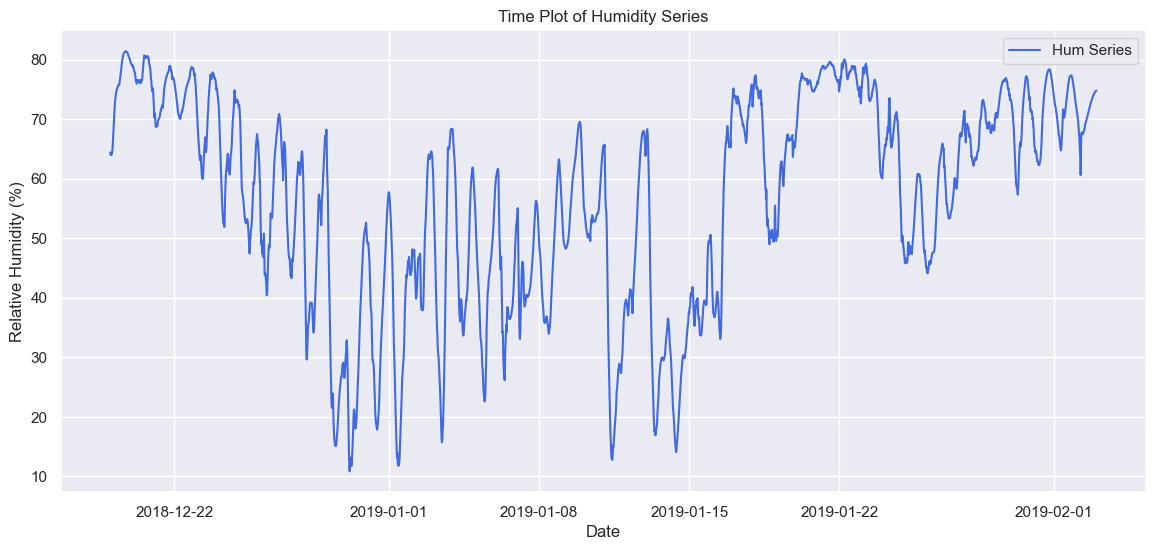

In [20]:
plt.figure(figsize=(14, 6))
plt.plot(hum_series, label='Hum Series', color='royalblue')
plt.title('Time Plot of Humidity Series')
plt.xlabel('Date')
plt.ylabel('Relative Humidity (%)')
plt.legend()
plt.show()

## Trend Analysis

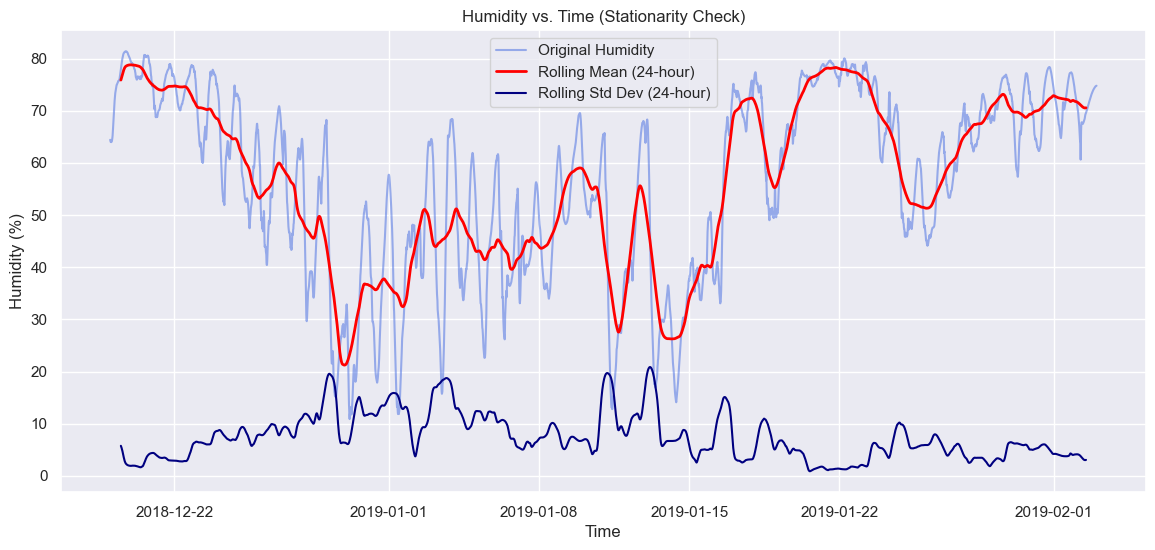

In [21]:
rolling_mean = hum_series.rolling(window=96, center=True).mean() # 96 periods of 15-min = 24 hours
rolling_std = hum_series.rolling(window=96, center=True).std()

plt.figure(figsize=(14, 6))
plt.plot(hum_series, label='Original Humidity', color='royalblue', alpha=0.5)
plt.plot(rolling_mean, label='Rolling Mean (24-hour)', color='red', linewidth=2)
plt.plot(rolling_std, label='Rolling Std Dev (24-hour)', color='navy')
plt.title(r'Humidity vs. Time (Stationarity Check)')
plt.xlabel('Time')
plt.ylabel(r'Humidity (%)')
plt.legend(loc='best')
plt.show()

## Seasonal Decomposition

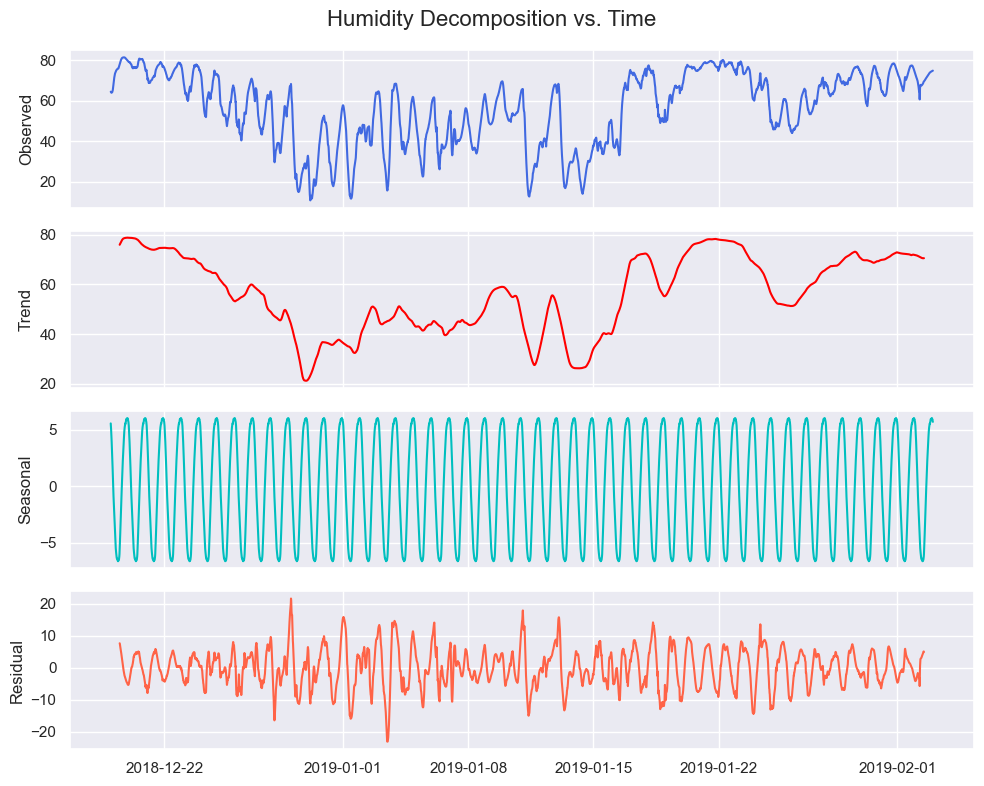

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(hum_series, model='additive', period=96)

fig, ax = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
ax[0].plot(decomposition.observed, color='royalblue')
ax[0].set_ylabel('Observed')
ax[1].plot(decomposition.trend, color='red')
ax[1].set_ylabel('Trend')
ax[2].plot(decomposition.seasonal, color='c')
ax[2].set_ylabel('Seasonal')
ax[3].plot(decomposition.resid, color='tomato')
ax[3].set_ylabel('Residual')
fig.suptitle(r'Humidity Decomposition vs. Time', fontsize=16)
plt.tight_layout()
plt.show()

## Boxplots

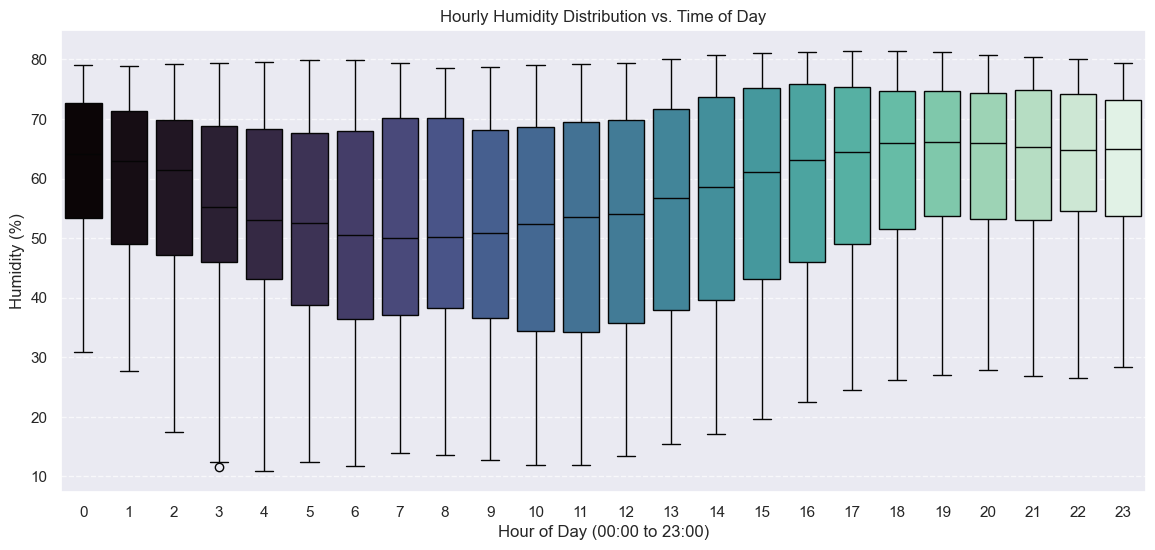

In [23]:
### daily cycle boxplot
df_plot = data.copy()

### extract the hour (0 to 23) from the datetime index
df_plot['Hour'] = df_plot.index.hour

### plot the hourly distribution
plt.figure(figsize=(14, 6))
sns.boxplot(x='Hour', y='relative_hum_Ice', data=df_plot, palette='mako', hue='Hour', legend=False)
plt.title(r'Hourly Humidity Distribution vs. Time of Day')
plt.xlabel('Hour of Day (00:00 to 23:00)')
plt.ylabel(r'Humidity (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

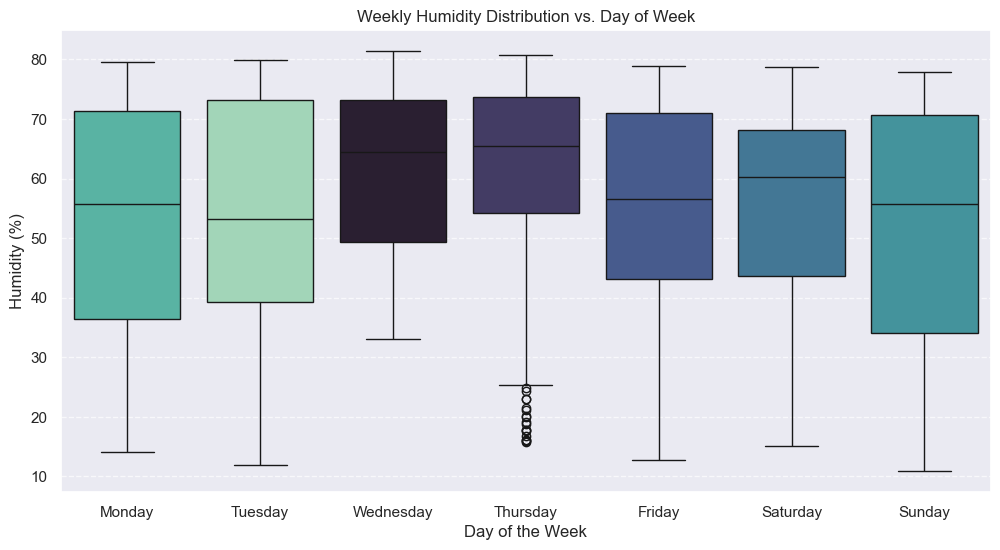

In [24]:
### weekly cycle boxplot

### extract the day name from the datetime index
df_plot['Day'] = data.index.day_name()

### chronologically order days
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

### plot weekly distribution
plt.figure(figsize=(12, 6))
sns.boxplot(x='Day', y='relative_hum_Ice', data=df_plot, order=days_order, palette='mako', hue='Day', legend=False)

plt.title(r'Weekly Humidity Distribution vs. Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel(r'Humidity (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Autocorrelation Plots

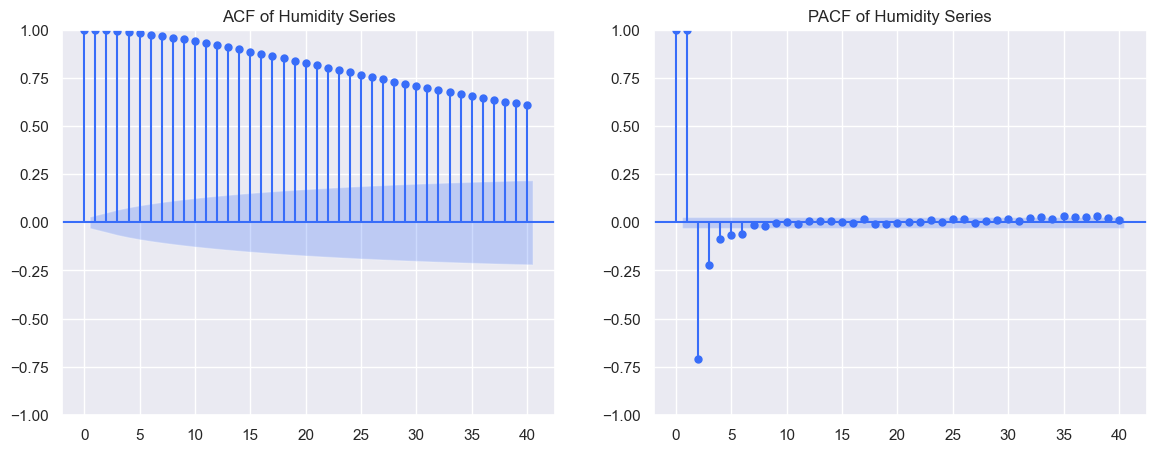

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(hum_series, lags=40, ax=ax[0])
ax[0].set_title('ACF of Humidity Series')
plot_pacf(hum_series, lags=40, method='ywm', ax=ax[1])
ax[1].set_title('PACF of Humidity Series')
plt.show()

## Stationarity and Augmented Dickey-Fuller Test

In [26]:
from statsmodels.tsa.stattools import adfuller

adf_stat, adf_pvalue, _, _, _, _ = adfuller(hum_series.dropna())
print(f'ADF Test Statistic: {adf_stat:.3f}')
print(f'ADF p-value: {adf_pvalue:.3f}')

ADF Test Statistic: -5.775
ADF p-value: 0.000


## Differencing

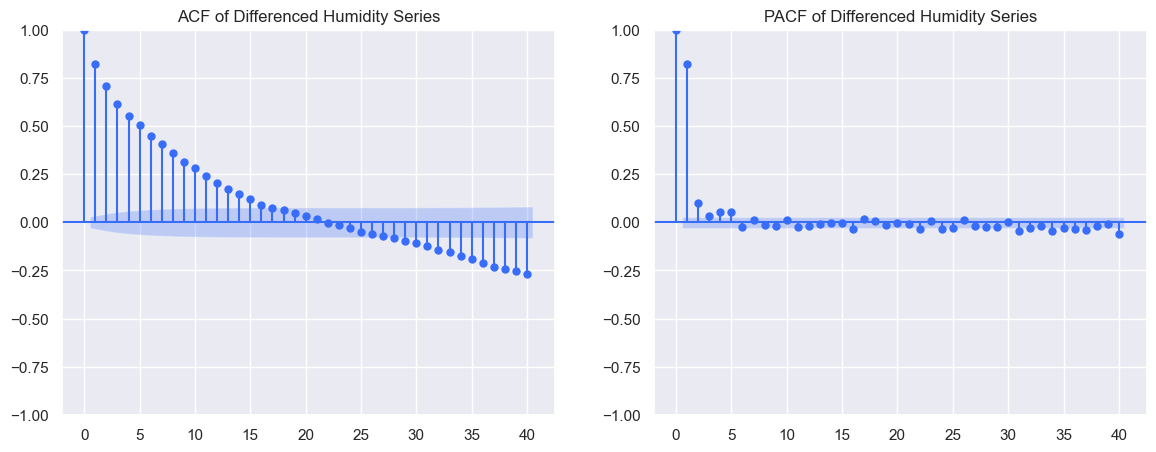

In [27]:
hum_series_diff = hum_series.diff().dropna()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(hum_series_diff, lags=40, ax=ax[0])
ax[0].set_title('ACF of Differenced Humidity Series')
plot_pacf(hum_series_diff, lags=40, ax=ax[1], method='ywm')
ax[1].set_title('PACF of Differenced Humidity Series')
plt.show()

## Detect Outliers

In [28]:
# detect outliers using 3 sigma rule
mean_hs = hum_series.mean()
std_hs = hum_series.std()
upper_bound = mean_hs + 3*std_hs
lower_bound = mean_hs - 3*std_hs
outliers = hum_series[(hum_series > upper_bound) | (hum_series < lower_bound)]
print('Detected outlier(s):')
print(outliers)

Detected outlier(s):
Series([], Freq: 15min, Name: relative_hum_Ice, dtype: float64)
